In [1]:
%run ./00_setup.ipynb
leases = pd.read_parquet(INTERIM_DIR / "leases.parquet")
concessions = pd.read_parquet(INTERIM_DIR / "concessions.parquet")
lease_pairs = pd.read_parquet(INTERIM_DIR / "lease_pairs.parquet")

listings      1,061 rows  29 columns
leases        4,302 rows  35 columns
concessions   3,560 rows  18 columns
asking        3,857 rows  14 columns
Columns dropped from leases: ['available_date', 'property_type', 'furnishing', 'smoking', 'cats_allowed', 'dogs_allowed']
leases: 4,302 rows, 33 columns


## 5. Concessions: contract rent vs effective rent

### 5.1 How often and how deep concessions are, per year
Per year and lease type: the share of leases with a concession, and the average depth `1 − effective/contract`.
We need both: depth is how much gets given back, frequency is how many leases get something.

In [2]:
concession_by_lease = leases[["unit_id", "lease_year", "province", "lease_type", "has_concession",
                              "rent_contract", "rent_effective", "concession_depth", "term_months"]].copy()
concession_yearly = (concession_by_lease[concession_by_lease.lease_year >= FIRST_ANALYSIS_YEAR]
                     .groupby(["lease_year", "lease_type"])
                     .agg(leases=("has_concession", "size"), share_with_concession=("has_concession", "mean"),
                          mean_depth=("concession_depth", "mean"))
                     .reset_index())
concession_yearly.pivot(index="lease_year", columns="lease_type",
                        values=["share_with_concession", "mean_depth"]).mul(PCT).round(1)

share_with_concession          mean_depth         
lease_type               renewal turnover    renewal turnover
lease_year                                                   
2018                        43.1     36.4        1.6      1.3
2019                        48.5     42.4        1.8      1.6
2020                        47.8     50.0        2.1      2.1
2021                        53.8     54.4        2.7      2.7
2022                        59.9     54.2        3.5      3.1
2023                        47.6     57.9        3.2      3.8
2024                        68.5     77.2        5.4      6.0
2025                        88.6     82.1        9.5      8.8

### 5.2 Which kinds of concessions, and how `PromoPay` looks per month
For each concession start year, the share of leases that receive each code. The one-off credit
(`one_time_promo_credit`) is **spread over the lease** (`amount / term_months`) so it compares with a monthly rent.

In [3]:
lease_terms = leases.groupby(["unit_id", "lease_year"])[["term_months", "rent_contract"]].first()
concessions_by_year = concessions.assign(lease_year=concessions.concession_start.dt.year).join(
    lease_terms, on=["unit_id", "lease_year"], how="inner")
leases_per_year = leases.groupby("lease_year").size()
code_share = (concessions_by_year.groupby(["lease_year", "concession_code"]).unit_id.nunique()
              .unstack().div(leases_per_year, axis=0).loc[FIRST_ANALYSIS_YEAR:DATA_CUTOFF.year])
promo = concessions_by_year[concessions_by_year.concession_code == "one_time_promo_credit"]
promo_monthly_share = (-promo.concession_amount / promo.term_months / promo.rent_contract).groupby(promo.lease_year).median()
print("Promo credit spread over the lease, as % of monthly rent (median):")
print((promo_monthly_share * PCT).round(2).loc[FIRST_ANALYSIS_YEAR:].to_string())
(code_share * PCT).round(1)

Promo credit spread over the lease, as % of monthly rent (median):
lease_year
2018    3.16
2019    3.98
2020    3.64
2021    4.13
2022    4.78
2023    5.87
2024    6.73
2025    7.69


concession_code,Freeothe,Indem,Referenc,freeappl,freelock,freepark,freerent,one_time_promo_credit
lease_year,,,,,,,,
2018,6.4,1.2,1.2,0.6,3.5,9.3,2.9,11.6
2019,7.9,0.9,0.6,0.6,3.4,11.9,1.8,13.7
2020,9.7,1.6,0.5,0.5,2.4,15.3,3.2,23.6
2021,11.1,1.4,0.3,1.1,2.8,15.0,1.9,27.4
2022,11.6,1.2,0.5,0.5,2.6,20.4,3.1,24.2
2023,8.7,1.0,0.6,0.3,4.9,19.0,3.5,22.2
2024,14.4,2.7,1.2,1.3,4.3,25.3,4.9,26.8
2025,16.4,1.1,1.0,1.8,4.8,25.6,4.3,35.1


### 5.3 Contract vs effective growth (same apartment)

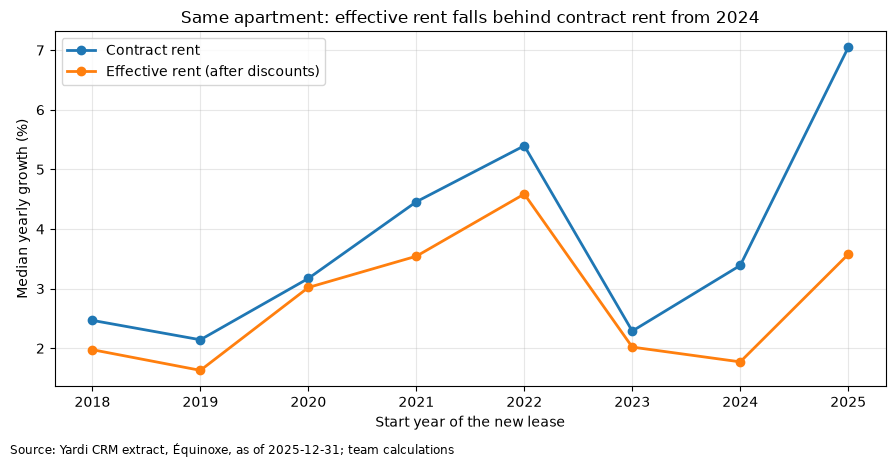

,median_contract,median_effective,mean_prev_depth,mean_depth,gap_pp,pairs
lease_year,,,,,,
2018,2.47,1.98,1.21,1.36,-0.49,88
2019,2.14,1.63,1.36,1.78,-0.51,159
2020,3.17,3.02,1.77,2.07,-0.15,331
2021,4.46,3.54,2.02,2.68,-0.91,355
2022,5.40,4.59,2.74,3.35,-0.81,352
2023,2.29,2.02,3.21,3.24,-0.27,416
2024,3.39,1.77,3.66,5.46,-1.62,698
2025,7.04,3.58,5.79,9.24,-3.47,780


In [4]:
growth_contract_vs_effective = lease_pairs.groupby("lease_year").agg(
    pairs=("growth_contract", "size"),
    median_contract=("growth_contract", "median"),
    median_effective=("growth_effective", "median"),
    mean_prev_depth=("prev_concession_depth", "mean"),
    mean_depth=("concession_depth", "mean"),
)
growth_contract_vs_effective["gap_pp"] = (growth_contract_vs_effective.median_effective
                                          - growth_contract_vs_effective.median_contract)

fig, ax = plt.subplots(figsize=FIGSIZE)
shown = growth_contract_vs_effective.loc[FIRST_ANALYSIS_YEAR:]
ax.plot(shown.index, shown.median_contract * PCT, "o-", label="Contract rent")
ax.plot(shown.index, shown.median_effective * PCT, "o-", label="Effective rent (after discounts)")
ax.set_title("Same apartment: effective rent falls behind contract rent from 2024")
ax.set_xlabel("Start year of the new lease")
ax.set_ylabel("Median yearly growth (%)")
ax.legend()
add_source(fig)
plt.tight_layout()
plt.show()
(shown.drop(columns="pairs") * PCT).round(2).assign(pairs=shown.pairs)

### 5.4 Why the two growth rates split from 2024
For one pair, this identity is exact:

$$(1+g_{eff}) = (1+g_{contract}) \times \frac{1 - d_{new}}{1 - d_{previous}}$$

where $d$ is the concession depth. When the depth **rises** between the previous lease and the new one, effective growth
falls below contract growth. Below we check that this decomposition reproduces the observed gap.

In [5]:
decomposed = lease_pairs.assign(
    implied_effective=(1 + lease_pairs.growth_contract) ** lease_pairs.gap_years
    * (1 - lease_pairs.concession_depth) / (1 - lease_pairs.prev_concession_depth))
decomposed["implied_effective"] = decomposed.implied_effective ** (1 / decomposed.gap_years) - 1
max_abs_error = (decomposed.implied_effective - decomposed.growth_effective).abs().max()
print(f"Max gap between observed and decomposed effective growth: {max_abs_error:.2e} (exact identity)")

Max gap between observed and decomposed effective growth: 4.44e-16 (exact identity)


**What it means for an owner:**
- Up to 2023, the two curves stay within one point of each other: concessions exist, but their depth barely changes.
- In 2024 and especially 2025, the average **depth** of concessions climbs (about 4 % → 9 % of rent), and nearly every lease gets one.
  Équinoxe posts high contract increases (≈ 7 % in 2025) but gives part of it back (promo credits, free parking):
  the increase actually collected is only about 3.6 %.
- This fits the market: CMHC reports rising vacancy in 2025 and more incentives (free months, bonuses) in big cities (§7).
- **Which one to quote?** For the revenue budget: **effective** (our headline). For renewal notices and the TAL / Ontario rules: **contract**.

In [6]:
concession_by_lease.to_parquet(INTERIM_DIR / "concession_by_lease.parquet")
concession_yearly.to_parquet(INTERIM_DIR / "concession_yearly.parquet")
growth_contract_vs_effective.to_parquet(INTERIM_DIR / "growth_contract_vs_effective.parquet")